In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [69]:
q_file = "bottom_boundary_discharge.txt"
h_file = "gauge_0.txt"

In [124]:
q_data = pd.read_csv(q_file, skiprows=0, sep=' ', header=0)
h_data = pd.read_csv(h_file, skiprows=1, sep=' ', header=0)
rain_data = pd.read_csv("cstRain-test3.txt", skiprows=0, sep='\t', header=None, names=['Time(s)', 'Rainfall(mm/h)'])

In [123]:
rain_data

,Time(s),Rainfall(mm/h)
0,0.0,328.0
1,25.0,328.0
2,25.1,0.0
3,32.0,328.0
4,57.0,328.0
5,57.1,0.0
6,150.0,0.0


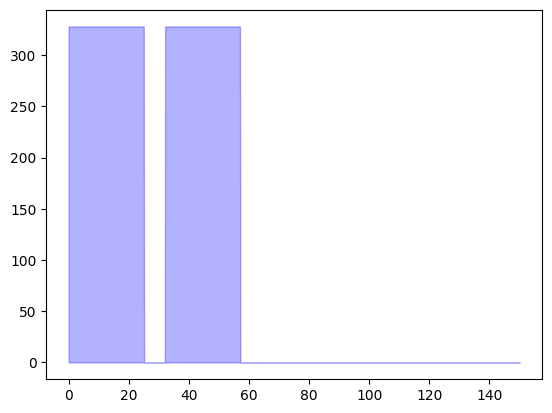

In [129]:
plt.fill_between(rain_data['Time(s)'], rain_data['Rainfall(mm/h)'],color='blue', label='Rain rate', alpha=0.3)

In [ ]:
mea = pd.read_csv("../CEA_C1-C3_datasets.csv", skiprows=1, delimiter =',', header=0)
mea.columns = ['t1','q1','t2','q2']

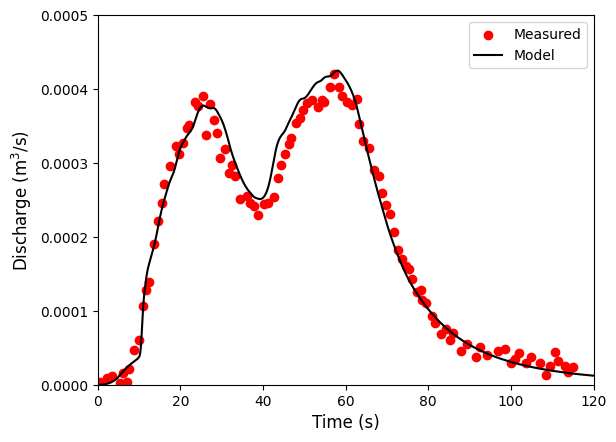

In [131]:
plt.scatter(mea['t2'], mea['q2'], color='red', label='Measured')
plt.plot(q_data["Time(s)"],q_data["Discharge(m3/s)"], color='k', label='Model')
plt.xlim(0, 120)
plt.ylim(0, 0.0005)
plt.legend()
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Discharge (m$^3$/s)', fontsize=12)
plt.savefig('cea_c3_discharge.png', dpi=300, bbox_inches='tight', transparent=True)

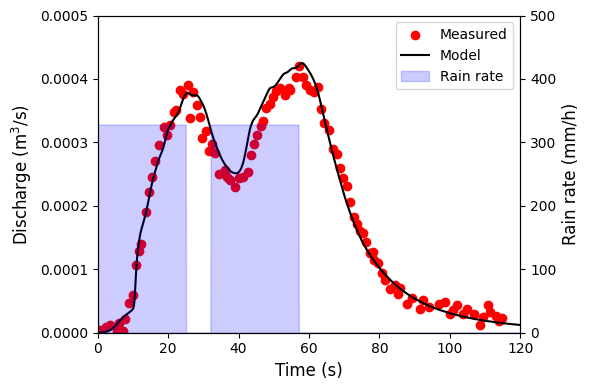

In [144]:
fig, ax1 = plt.subplots(figsize=(6, 4))

# Left axis: discharge
ax1.scatter(mea['t2'], mea['q2'], color='red', label='Measured')
ax1.plot(q_data["Time(s)"],q_data["Discharge(m3/s)"], color='k', label='Model')
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Discharge (m$^3$/s)', fontsize=12)
ax1.set_xlim(0, 120)
ax1.set_ylim(0, 0.0005)

# Right axis: rainfall
ax2 = ax1.twinx()
ax2.fill_between(rain_data['Time(s)'], rain_data['Rainfall(mm/h)'],color='blue', label='Rain rate', alpha=0.2)
ax2.set_ylabel('Rain rate (mm/h)', fontsize=12)
ax2.set_ylim(0, 500)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.savefig('cea_c3_discharge_rainfall.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

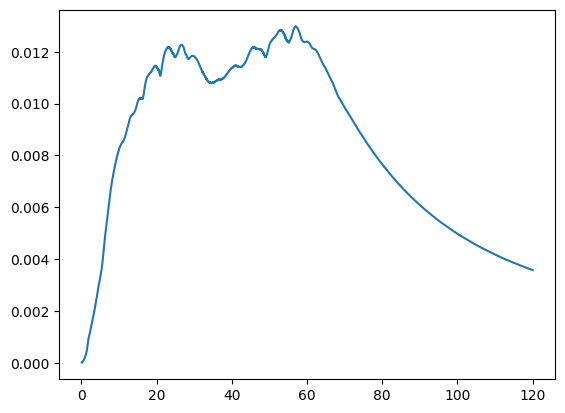

In [104]:
gauge = pd.read_csv("gauge_3.txt", skiprows=1, sep=' ', header=0)
plt.plot(gauge['Time(s)'],gauge['Depth(m)'])

In [46]:
gauge

,Time(s),dt(s),Depth(m),Elevation(m)
0,0.100000,0.100000,0.000009,-0.274866
1,0.200000,0.100000,0.000000,-0.274875
2,0.203556,0.003556,0.000000,-0.274875
3,0.206537,0.002982,0.000001,-0.274874
4,0.209514,0.002977,0.000001,-0.274874
...,...,...,...,...
88511,119.995781,0.001123,0.232071,-0.042804
88512,119.996904,0.001123,0.232071,-0.042804
88513,119.998027,0.001123,0.232071,-0.042804
88514,119.999150,0.001123,0.232071,-0.042804


In [23]:
import xarray as xr

In [30]:
ds

<xarray.Dataset> Size: 367kB
Dimensions:  (y: 250, x: 182)
Coordinates:
  * y        (y) float64 2kB 0.03 0.04 0.05 0.06 0.07 ... 2.49 2.5 2.51 2.52
  * x        (x) float64 1kB 0.205 0.215 0.225 0.235 ... 1.985 1.995 2.005 2.015
Data variables:
    hmax     (y, x) float64 364kB ...
Attributes:
    description:  Maximum water depth
    units:        metres

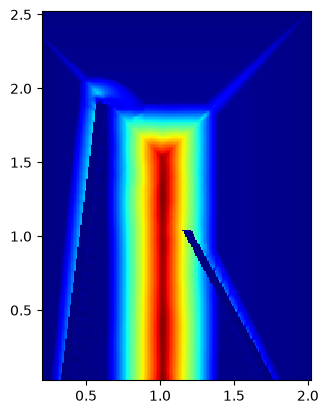

In [35]:
ds = xr.open_dataset("hmax_test.nc")
plt.pcolormesh(ds["x"],ds["y"],ds["hmax"], cmap="jet")
plt.gca().set_aspect('equal', adjustable='box')

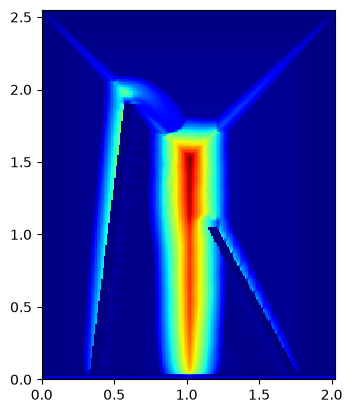

In [33]:
ds = xr.open_dataset("hmax.nc")
plt.pcolormesh(ds["x"],ds["y"],ds["hmax"], cmap="jet")
plt.gca().set_aspect('equal', adjustable='box')